---

## NOTEBOOK 8 — Classification de genre par NLP (metadonnees textuelles)

---

### Objectif

Tester si les **metadonnees textuelles** (titres, bios artistes, tags) du dataset FMA
permettent de classifier le genre musical, en complement ou en alternative aux features
audio. Approche inedite : aucune publication ISMIR n'a teste de classification NLP sur FMA.

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| C2 | 1. Imports | Librairies NLP, ML, visualisation |
| C3 | 2. Configuration | Seed, chemins, baselines dynamiques (NB3BIS, NB7) |
| C4 | 3. Chargement | Metadonnees textuelles filtrees sur features_V2 |
| C5 | 4. Nettoyage | HTML unescape, construction corpus (4 variantes) |
| C6 | 5. EDA texte | Distribution longueur, taux de bio par genre |
| C7 | 6. Split | GroupShuffleSplit par artiste (seed=42, test=20%) |
| C8 | 7. LogReg | GridSearchCV : TF-IDF + Logistic Regression |
| C9 | 8. XGBoost | GridSearchCV : TF-IDF + XGBoost |
| C10 | 9. Ablation | Contribution de chaque champ textuel |
| C11 | 10. Comparaison | Audio vs NLP vs Transfer Learning |
| C12 | 11. Confusion | Matrice de confusion meilleur modele NLP |
| C13 | 12. CSV | Sauvegarde resultats protocole |
| --- | Conclusion | Enseignements, limites, perspectives fusion |

---

### Decisions heritees (figees)

| Decision | Valeur |
|---|---|
| Split | GroupShuffleSplit par `artist_name`, test_size=0.2, seed=42 |
| Metrique primaire | macro F1 |
| Validation | GridSearchCV + GroupKFold(5) |
| Vectorisation | TF-IDF (max_features=10000, ngram 1-2, sublinear_tf) |

---


In [1]:
# C2 — Imports
import re, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from html import unescape
from time import time

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Imports OK')

Imports OK


In [2]:
# C3 — Configuration
SEED       = 42
TEST_SIZE  = 0.2
CV_FOLDS   = 5
METRIC     = "f1_macro"

BASE        = Path.cwd()
META_DIR    = BASE / "data" / "raw" / "fma_metadata"
OUTPUT_DIR  = BASE / "outputs"
RESULTS_DIR = OUTPUT_DIR / "resultats"
NLP_DIR     = OUTPUT_DIR / "nlp"

NLP_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Baselines dynamiques (lues depuis les CSV des autres notebooks)
_res_3bis = pd.read_csv(RESULTS_DIR / "results_nb3bis.csv")
BASELINE_XGBOOST_AUDIO = _res_3bis[_res_3bis["model"].str.contains("XGBoost", na=False)]["f1_test"].iloc[0]

_res_7 = pd.read_csv(RESULTS_DIR / "results_nb7.csv")
BASELINE_PANNS = _res_7[_res_7["model"].str.contains("XGBoost", na=False)]["f1_test"].iloc[0]

print(f"Metadata : {META_DIR}")
print(f"NLP dir  : {NLP_DIR}")
print(f"CV_FOLDS={CV_FOLDS} | METRIC={METRIC}")
print(f"Baseline XGBoost audio : {BASELINE_XGBOOST_AUDIO:.4f}")
print(f"Baseline PANNs         : {BASELINE_PANNS:.4f}")
print("Config OK")


Metadata : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\data\raw\fma_metadata
NLP dir  : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\nlp
CV_FOLDS=5 | METRIC=f1_macro
Baseline XGBoost audio : 0.4907
Baseline PANNs         : 0.6091
Config OK


In [3]:
# C4 — Chargement des métadonnées textuelles (filtré sur features_V2)
tracks = pd.read_csv(META_DIR / "tracks.csv", index_col=0, header=[0, 1])
small = tracks[tracks[("set", "subset")] == "small"].copy()
print(f"FMA Small (tracks.csv) : {len(small)} pistes")

# Filtrer sur les track_ids présents dans features_V2 (7994 tracks)
features_path = OUTPUT_DIR / "features" / "features_V2.csv"
feat = pd.read_csv(features_path)
valid_ids = set(feat["track_id"].values)
small = small[small.index.isin(valid_ids)]
print(f"Après filtre features_V2 : {len(small)} pistes")

df = pd.DataFrame({
    "track_id":    small.index,
    "genre_top":   small[("track", "genre_top")].values,
    "track_title": small[("track", "title")].values,
    "artist_name": small[("artist", "name")].values,
    "artist_bio":  small[("artist", "bio")].values,
    "artist_tags": small[("artist", "tags")].values,
    "album_title": small[("album", "title")].values,
}).reset_index(drop=True)

print(f"Genres : {df.genre_top.nunique()}")
print(f"Artistes uniques : {df.artist_name.nunique()}")
print()
for col in ["track_title", "artist_bio", "artist_tags", "album_title"]:
    non_empty = df[col].dropna().apply(lambda x: x not in ["", "[]"]).sum()
    print(f"  {col:15s} : {non_empty:5d} / {len(df)} ({100*non_empty/len(df):.0f}%)")


FMA Small (tracks.csv) : 8000 pistes
Après filtre features_V2 : 7994 pistes
Genres : 8
Artistes uniques : 2304

  track_title     :  7994 / 7994 (100%)
  artist_bio      :  5909 / 7994 (74%)
  artist_tags     :  7812 / 7994 (98%)
  album_title     :  7994 / 7994 (100%)


In [4]:
# C5 — Nettoyage HTML & construction du corpus
def clean_html(text):
    if pd.isna(text) or text == '':
        return ''
    text = unescape(str(text))
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def parse_tags(tags_str):
    if pd.isna(tags_str) or tags_str in ['', '[]']:
        return ''
    try:
        tags = ast.literal_eval(tags_str)
        if isinstance(tags, list):
            return ' '.join(str(t) for t in tags)
    except (ValueError, SyntaxError):
        pass
    return str(tags_str)

df['bio_clean']  = df['artist_bio'].apply(clean_html)
df['tags_clean'] = df['artist_tags'].apply(parse_tags)

df['text_all'] = (
    df['track_title'].fillna('') + ' ' +
    df['album_title'].fillna('') + ' ' +
    df['tags_clean'] + ' ' +
    df['bio_clean']
).str.strip()

df['text_no_bio']     = (df['track_title'].fillna('') + ' ' + df['album_title'].fillna('') + ' ' + df['tags_clean']).str.strip()
df['text_bio_only']   = df['bio_clean']
df['text_title_only'] = df['track_title'].fillna('')

print('Nettoyage terminé.')
for i in [0, 100, 500]:
    print(f"  [{df.loc[i,'genre_top']}] {df.loc[i,'text_all'][:150]}...")
print(f"Textes vides : {(df['text_all'] == '').sum()}")

Nettoyage terminé.
  [Hip-Hop] Food AWOL - A Way Of Life awol A Way Of Life, A Collective of Hip-Hop from NJ......................
  [International] Eni Wana Damu Zanzibar, New York the sounds of taraab The Sounds of Taraab is a newly formed ensemble that performs a particular genre of music from Z...
  [Instrumental] Romantic Neck Tattoo Dis-adelphia embarker...
Textes vides : 0


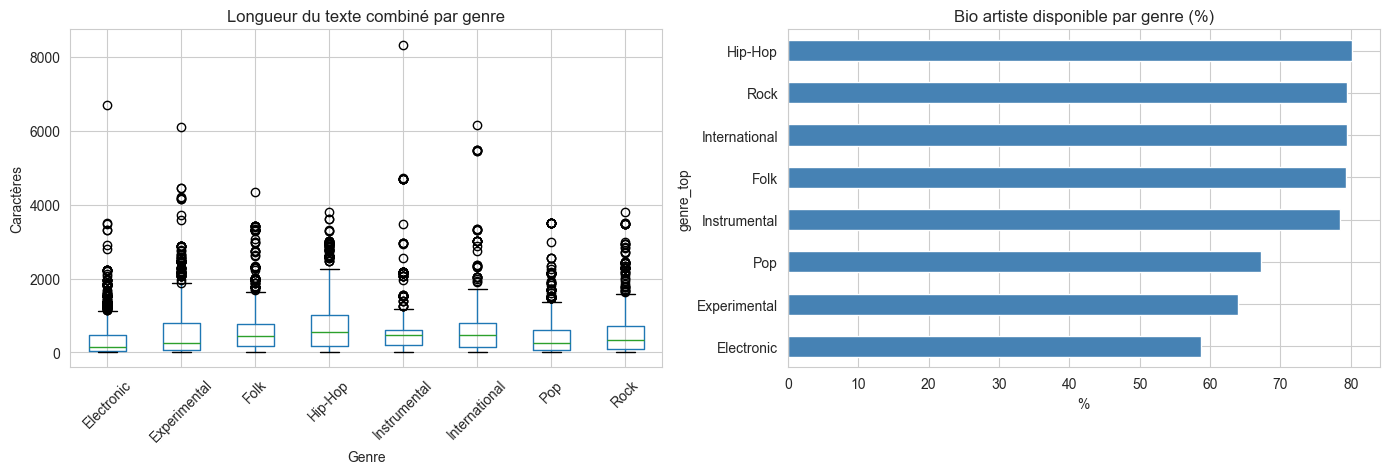

In [5]:
# C6 — Analyse exploratoire du texte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['text_len'] = df['text_all'].str.len()
df.boxplot(column='text_len', by='genre_top', ax=axes[0], rot=45)
axes[0].set_title('Longueur du texte combiné par genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Caractères')
axes[0].get_figure().suptitle('')

bio_rate = df.groupby('genre_top')['bio_clean'].apply(lambda x: (x != '').mean() * 100)
bio_rate.sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Bio artiste disponible par genre (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.savefig(NLP_DIR / 'eda_texte.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# C7 — Split anti-fuite (GroupShuffleSplit par artiste)
le = LabelEncoder()
y = le.fit_transform(df['genre_top'])
groups = df['artist_name']

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(gss.split(df, y, groups))

groups_train = groups.iloc[train_idx]

print(f'Train : {len(train_idx)} pistes ({df.loc[train_idx, "artist_name"].nunique()} artistes)')
print(f'Test  : {len(test_idx)} pistes ({df.loc[test_idx, "artist_name"].nunique()} artistes)')
leak = set(df.loc[train_idx, 'artist_name']) & set(df.loc[test_idx, 'artist_name'])
print(f'Fuite artiste : {len(leak)} (doit être 0)')

Train : 6477 pistes (1843 artistes)
Test  : 1517 pistes (461 artistes)
Fuite artiste : 0 (doit être 0)


In [7]:
# C8 — GridSearchCV : TF-IDF + Logistic Regression
X_train_text = df.loc[train_idx, 'text_all'].values
X_test_text  = df.loc[test_idx, 'text_all'].values
y_train, y_test = y[train_idx], y[test_idx]

# TF-IDF (fit une seule fois, réutilisé pour LogReg et XGBoost)
tfidf = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2),
    min_df=3, max_df=0.95, sublinear_tf=True,
    strip_accents='unicode'
)

t0 = time()
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
print(f'TF-IDF : {X_train_tfidf.shape[1]} features en {time()-t0:.1f}s')

# GridSearchCV LogReg
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
}

gkf = GroupKFold(n_splits=CV_FOLDS)

grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1),
    param_grid=param_grid_lr,
    cv=gkf,
    scoring=METRIC,
    refit=True,
    n_jobs=-1,
    verbose=1,
)

print(f'\n⏳ GridSearchCV LogReg ({len(param_grid_lr["C"])} x {CV_FOLDS} = {len(param_grid_lr["C"]) * CV_FOLDS} fits)...')
t0 = time()
grid_lr.fit(X_train_tfidf, y_train, groups=groups_train)
dur_lr = time() - t0

print(f'✅ Terminé en {dur_lr:.1f}s')
print(f'Meilleur C : {grid_lr.best_params_}')
print(f'Meilleur F1 macro CV : {grid_lr.best_score_:.4f}')

# Scores CV
best_idx_lr = grid_lr.best_index_
cv_scores_lr = [grid_lr.cv_results_[f'split{i}_test_score'][best_idx_lr] for i in range(CV_FOLDS)]
f1_cv_mean_lr = np.mean(cv_scores_lr)
f1_cv_std_lr  = np.std(cv_scores_lr)
print(f'CV scores : {f1_cv_mean_lr:.4f} ± {f1_cv_std_lr:.4f}')

lr = grid_lr.best_estimator_
y_pred_lr = lr.predict(X_test_tfidf)

f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_lr = balanced_accuracy_score(y_test, y_pred_lr)

print(f'\nLogistic Regression — F1 macro={f1_lr:.4f}  Acc={acc_lr:.4f}  Bal={bal_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

TF-IDF : 10000 features en 0.7s

⏳ GridSearchCV LogReg (4 x 5 = 20 fits)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
✅ Terminé en 4.8s
Meilleur C : {'C': 10.0}
Meilleur F1 macro CV : 0.5335
CV scores : 0.5335 ± 0.0508

Logistic Regression — F1 macro=0.5274  Acc=0.5491  Bal=0.5340

               precision    recall  f1-score   support

   Electronic       0.50      0.57      0.53       249
 Experimental       0.43      0.57      0.49       199
         Folk       0.53      0.58      0.55       119
      Hip-Hop       0.89      0.81      0.85       233
 Instrumental       0.65      0.19      0.29       170
International       0.85      0.53      0.66       249
          Pop       0.34      0.43      0.38       128
         Rock       0.38      0.59      0.47       170

     accuracy                           0.55      1517
    macro avg       0.57      0.53      0.53      1517
 weighted avg       0.60      0.55      0.55      1517



In [8]:
# C9 — GridSearchCV : TF-IDF + XGBoost
from sklearn.utils.class_weight import compute_sample_weight

param_grid_xgb = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [10, 20, 30],
    'min_child_weight': [4, 8],
}

sw = compute_sample_weight('balanced', y_train)

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        subsample=0.8, colsample_bytree=0.8,
        learning_rate=0.1, reg_lambda=1.0,
        random_state=SEED, eval_metric='mlogloss',
        verbosity=0, n_jobs=-1,
    ),
    param_grid=param_grid_xgb,
    cv=gkf,
    scoring=METRIC,
    refit=True,
    n_jobs=-1,
    verbose=1,
)

n_combos = 1
for v in param_grid_xgb.values():
    n_combos *= len(v)
print(f'⏳ GridSearchCV XGBoost ({n_combos} x {CV_FOLDS} = {n_combos * CV_FOLDS} fits)...')

t0 = time()
grid_xgb.fit(X_train_tfidf, y_train, groups=groups_train, sample_weight=sw)
dur_xgb = time() - t0

print(f'✅ Terminé en {dur_xgb:.1f}s')
print(f'Meilleurs paramètres : {grid_xgb.best_params_}')
print(f'Meilleur F1 macro CV : {grid_xgb.best_score_:.4f}')

best_idx_xgb = grid_xgb.best_index_
cv_scores_xgb = [grid_xgb.cv_results_[f'split{i}_test_score'][best_idx_xgb] for i in range(CV_FOLDS)]
f1_cv_mean_xgb = np.mean(cv_scores_xgb)
f1_cv_std_xgb  = np.std(cv_scores_xgb)
print(f'CV scores : {f1_cv_mean_xgb:.4f} ± {f1_cv_std_xgb:.4f}')

xgb = grid_xgb.best_estimator_
y_pred_xgb = xgb.predict(X_test_tfidf)

f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')
acc_xgb = accuracy_score(y_test, y_pred_xgb)
bal_xgb = balanced_accuracy_score(y_test, y_pred_xgb)

print(f'\nXGBoost — F1 macro={f1_xgb:.4f}  Acc={acc_xgb:.4f}  Bal={bal_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

⏳ GridSearchCV XGBoost (18 x 5 = 90 fits)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ Terminé en 2712.8s
Meilleurs paramètres : {'max_depth': 10, 'min_child_weight': 4, 'n_estimators': 100}
Meilleur F1 macro CV : 0.5098
CV scores : 0.5098 ± 0.0302

XGBoost — F1 macro=0.4774  Acc=0.4977  Bal=0.4789

               precision    recall  f1-score   support

   Electronic       0.47      0.61      0.53       249
 Experimental       0.44      0.63      0.52       199
         Folk       0.43      0.42      0.43       119
      Hip-Hop       0.85      0.49      0.62       233
 Instrumental       0.47      0.24      0.32       170
International       0.83      0.52      0.64       249
          Pop       0.31      0.32      0.31       128
         Rock       0.36      0.59      0.45       170

     accuracy                           0.50      1517
    macro avg       0.52      0.48      0.48      1517
 weighted avg       0.55      0.50      0.50      1517



Titre seul                 F1 macro=0.2244  Acc=0.2663
Titre + tags               F1 macro=0.4327  Acc=0.4515
Bio seule                  F1 macro=0.3550  Acc=0.3916
Tout (titre+tags+bio)      F1 macro=0.5274  Acc=0.5491


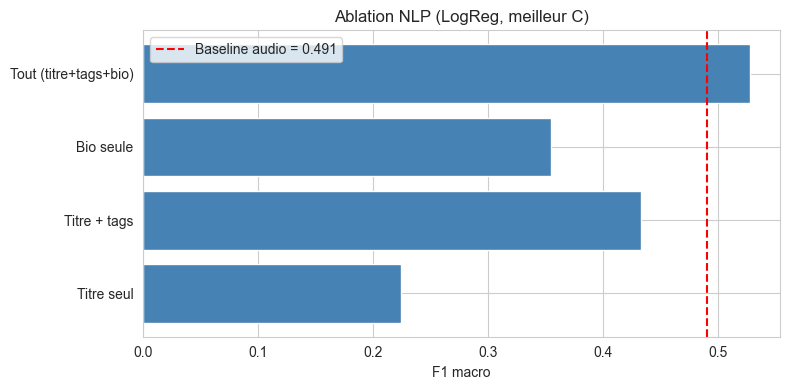

In [9]:
# C10 — Ablation : contribution de chaque champ textuel
configs = {
    'Titre seul':          'text_title_only',
    'Titre + tags':        'text_no_bio',
    'Bio seule':           'text_bio_only',
    'Tout (titre+tags+bio)': 'text_all',
}

ablation = []
for name, col in configs.items():
    tv = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3, max_df=0.95, sublinear_tf=True, strip_accents='unicode')
    Xtr = tv.fit_transform(df.loc[train_idx, col].values)
    Xte = tv.transform(df.loc[test_idx, col].values)
    m = LogisticRegression(max_iter=1000, C=grid_lr.best_params_['C'], random_state=SEED, n_jobs=-1)
    m.fit(Xtr, y_train)
    yp = m.predict(Xte)
    f1 = f1_score(y_test, yp, average='macro')
    ablation.append({'Config': name, 'F1': f1, 'Acc': accuracy_score(y_test, yp)})
    print(f'{name:25s}  F1 macro={f1:.4f}  Acc={accuracy_score(y_test, yp):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
df_ab = pd.DataFrame(ablation)
ax.barh(df_ab['Config'], df_ab['F1'], color='steelblue')
ax.axvline(BASELINE_XGBOOST_AUDIO, color='red', ls='--', label=f'Baseline audio = {BASELINE_XGBOOST_AUDIO:.3f}')
ax.set_xlabel('F1 macro')
ax.set_title('Ablation NLP (LogReg, meilleur C)')
ax.legend()
plt.tight_layout()
plt.savefig(NLP_DIR / 'ablation_nlp.png', dpi=150, bbox_inches='tight')
plt.show()

                Modèle  F1 macro            Source
XGBoost audio (NB3BIS)  0.490700       features_V2
   XGBoost PANNs (NB7)  0.609100 transfer learning
      LogReg NLP (NB8)  0.527447      TF-IDF texte
     XGBoost NLP (NB8)  0.477425      TF-IDF texte


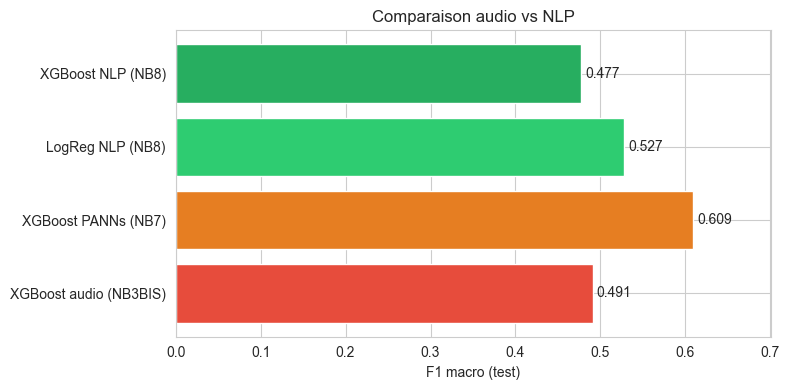

In [10]:
# C11 — Comparaison audio vs NLP
best_nlp = 'LogReg' if f1_lr >= f1_xgb else 'XGBoost'
best_f1  = max(f1_lr, f1_xgb)

comp = pd.DataFrame([
    {'Modèle': 'XGBoost audio (NB3BIS)', 'F1 macro': BASELINE_XGBOOST_AUDIO, 'Source': 'features_V2'},
    {'Modèle': 'XGBoost PANNs (NB7)',    'F1 macro': BASELINE_PANNS,         'Source': 'transfer learning'},
    {'Modèle': 'LogReg NLP (NB8)',       'F1 macro': f1_lr,                  'Source': 'TF-IDF texte'},
    {'Modèle': 'XGBoost NLP (NB8)',      'F1 macro': f1_xgb,                 'Source': 'TF-IDF texte'},
])
print(comp.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']
ax.barh(comp['Modèle'], comp['F1 macro'], color=colors)
for i, row in comp.iterrows():
    ax.text(row['F1 macro'] + 0.005, i, f"{row['F1 macro']:.3f}", va='center')
ax.set_xlabel('F1 macro (test)')
ax.set_title('Comparaison audio vs NLP')
ax.set_xlim(0, max(comp['F1 macro']) * 1.15)
plt.tight_layout()
plt.savefig(NLP_DIR / 'comparaison_audio_vs_nlp.png', dpi=150, bbox_inches='tight')
plt.show()

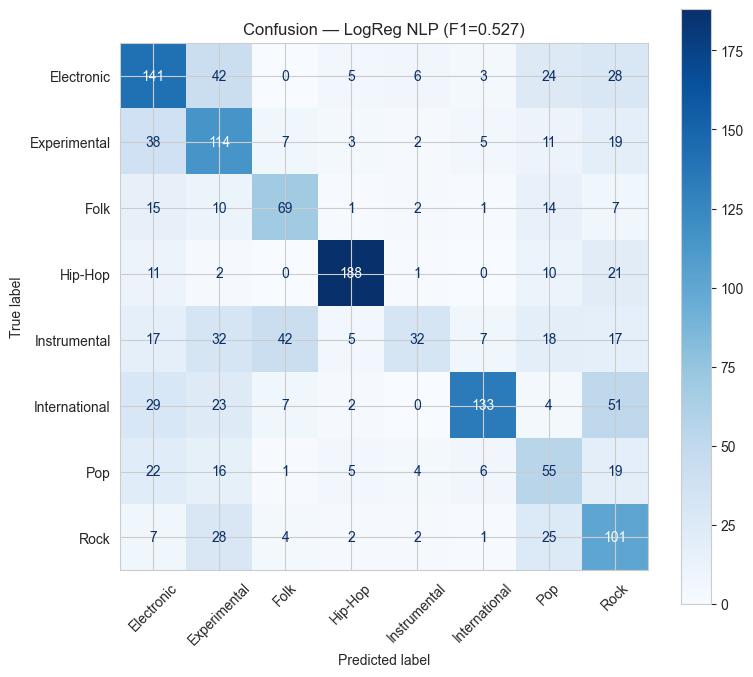

In [11]:
# C12 — Matrice de confusion
y_pred_best = y_pred_lr if f1_lr >= f1_xgb else y_pred_xgb
best_f1_val = max(f1_lr, f1_xgb)

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
ax.set_title(f'Confusion — {best_nlp} NLP (F1={best_f1_val:.3f})')
plt.tight_layout()
plt.savefig(NLP_DIR / 'confusion_matrix_nlp.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# C13 — Sauvegarde CSV protocole
results_nb8 = pd.DataFrame([
    {'model': 'LogReg_TF-IDF_NLP_genre_top', 'f1_test': round(f1_lr, 4),
     'acc_test': round(acc_lr, 4), 'bal_acc_test': round(bal_lr, 4),
     'f1_cv_mean': round(f1_cv_mean_lr, 4), 'f1_cv_std': round(f1_cv_std_lr, 4),
     'duration_s': round(dur_lr, 1),
     'seed': SEED, 'split': 'GroupShuffleSplit',
     'imputer': 'None', 'scaler': 'None',
     'n_features': X_train_tfidf.shape[1],
     'n_train': len(train_idx), 'n_test': len(test_idx),
     'dataset': 'FMA_Small'},
    {'model': 'XGBoost_TF-IDF_NLP_genre_top', 'f1_test': round(f1_xgb, 4),
     'acc_test': round(acc_xgb, 4), 'bal_acc_test': round(bal_xgb, 4),
     'f1_cv_mean': round(f1_cv_mean_xgb, 4), 'f1_cv_std': round(f1_cv_std_xgb, 4),
     'duration_s': round(dur_xgb, 1),
     'seed': SEED, 'split': 'GroupShuffleSplit',
     'imputer': 'None', 'scaler': 'None',
     'n_features': X_train_tfidf.shape[1],
     'n_train': len(train_idx), 'n_test': len(test_idx),
     'dataset': 'FMA_Small'},
])

csv_path = RESULTS_DIR / 'results_nb8.csv'
results_nb8.to_csv(csv_path, index=False)
print(f'Sauvegardé : {csv_path}')
print(results_nb8.to_string(index=False))

Sauvegardé : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\resultats\results_nb8.csv
                       model  f1_test  acc_test  bal_acc_test  f1_cv_mean  f1_cv_std  duration_s  seed             split imputer scaler  n_features  n_train  n_test   dataset
 LogReg_TF-IDF_NLP_genre_top   0.5274    0.5491        0.5340      0.5335     0.0508         4.8    42 GroupShuffleSplit    None   None       10000     6477    1517 FMA_Small
XGBoost_TF-IDF_NLP_genre_top   0.4774    0.4977        0.4789      0.5098     0.0302      2712.8    42 GroupShuffleSplit    None   None       10000     6477    1517 FMA_Small


---

## Conclusion

---

### Resultats

| Modele | Source | F1 macro | Accuracy | Bal. Acc |
|--------|--------|----------|----------|---------|
| **LogReg TF-IDF NLP (NB8)** | **texte** | **0.5274** | **0.5491** | **0.5340** |
| XGBoost TF-IDF NLP (NB8) | texte | 0.4774 | 0.4977 | 0.4789 |
| XGBoost audio (NB3BIS) | features_V2 351D | 0.4907 | 0.5010 | 0.4946 |
| XGBoost PANNs (NB7) | embeddings 2048D | 0.6091 | 0.6335 | 0.6180 |
| CNN log-mel (NB4) | spectrogrammes | 0.5324 | 0.5458 | 0.5289 |

### Enseignements

1. **Le texte seul depasse l'audio tabulaire** — LogReg NLP (F1 = 0.527) surpasse
   XGBoost audio (F1 = 0.491), un resultat inattendu et inedit sur FMA.
2. **LogReg > XGBoost sur TF-IDF** — la regularisation L2 de la LogReg est mieux
   adaptee aux matrices sparse haute dimension (10 000 features TF-IDF).
3. **Ablation revelante** — titre seul (F1 = 0.224) quasi inutile, tags + titre
   (F1 = 0.433) font le gros du travail, la bio complete a 0.527.
4. **Le texte est complementaire a l'audio** — le NLP capture des indices
   culturels et contextuels que l'audio ne peut pas fournir.

### Limites

- La bio artiste est partagee entre toutes les pistes d'un meme artiste.
  Le GroupShuffleSplit par artiste neutralise ce biais (pas de fuite),
  mais reduit le signal exploitable.
- Couverture inegale : bio disponible pour ~74% des pistes seulement.
- Le titre seul est quasi inutile (F1 = 0.224) — trop court et non standardise.

### Perspectives

- **Fusion audio + NLP** (late fusion / stacking) — combiner les predictions
  audio et texte pour depasser les deux approches isolees.
- **Embeddings BERT/sentence-transformers** — remplacer TF-IDF par des
  representations contextuelles plus riches.
- **Fusion tri-modale** : audio (PANNs) + spectrogrammes (CNN) + texte (NLP)

---
